In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("clustering_data.csv")
print(df.columns)

FileNotFoundError: [Errno 2] No such file or directory: 'clustering_data.csv'

In [ ]:
#1 Data filtering and taking my home state (AP)

df_state = df[ df["StateName"]=="ANDHRA PRADESH"].copy()
print("Total rows in state:", len(df_state))

# Drop missing values
df_state = df_state.dropna(subset=['Latitude', 'Longitude'])

# Remove duplicates
df_state = df_state.drop_duplicates(subset=['Pincode'])

# Reset index
df_state = df_state.reset_index(drop=True)

Total rows in state: 10634


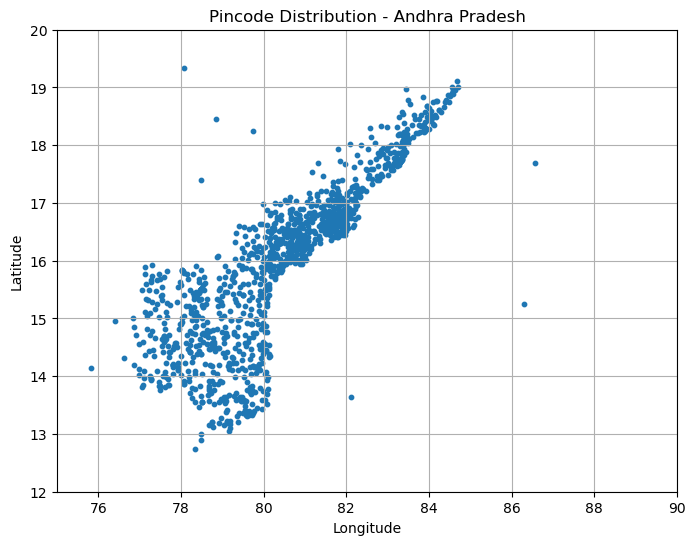

In [ ]:
#2 Data Visualization:
import matplotlib.pyplot as plt

df_state['Longitude'] = pd.to_numeric(df_state['Longitude'], errors='coerce')
df_state['Latitude'] = pd.to_numeric(df_state['Latitude'], errors='coerce')

plt.figure(figsize=(8,6))
plt.scatter(df_state['Longitude'], df_state['Latitude'], s=10)
plt.title("Pincode Distribution - Andhra Pradesh")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(75, 90)
plt.ylim(12, 20)
plt.grid()
plt.show()

In [ ]:
#3Clustering Analysis:

#initialisng centroids
def initialize_centroids(X, k):
    indices = np.random.choice(len(X), k, replace=False)
    return X[indices]

#assign clusters
def assign_clusters(X, centroids):
    labels = []

    for point in X:
        distances = []

        for centroid in centroids:
            dist = np.sqrt( (point[0] - centroid[0])**2 + (point[1] - centroid[1])**2 )
            distances.append(dist)

        cluster = np.argmin(distances) # storing indices of min dist..
        labels.append(cluster)

    return np.array(labels)

#update centroids
def update_centroids(X, labels, k):
    new_centroids = []

    for i in range(k):
        cluster_points = X[labels == i]
        # mean of a clustered point (new centroid)
        if len(cluster_points) > 0:
            new_centroids.append(cluster_points.mean(axis=0))
        else:
            # reinitialize if cluster is empty // random
            new_centroids.append(X[ np.random.randint( 0, len(X))])

    return np.array(new_centroids)

# K-Means
def kmeans(X, k, max_iters=100):
    centroids = initialize_centroids(X, k)

    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)

        # stop if centroids don't change
        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels, centroids

#Apply K-means

# Remove outliers (valid India range)
df_state = df_state[
    (df_state['Latitude'].between(12, 20)) &
    (df_state['Longitude'].between(75, 90))]

X = df_state[['Longitude', 'Latitude']].values

k = 4  # you can tune this
labels, centroids = kmeans(X, k)

df_state['cluster'] = labels


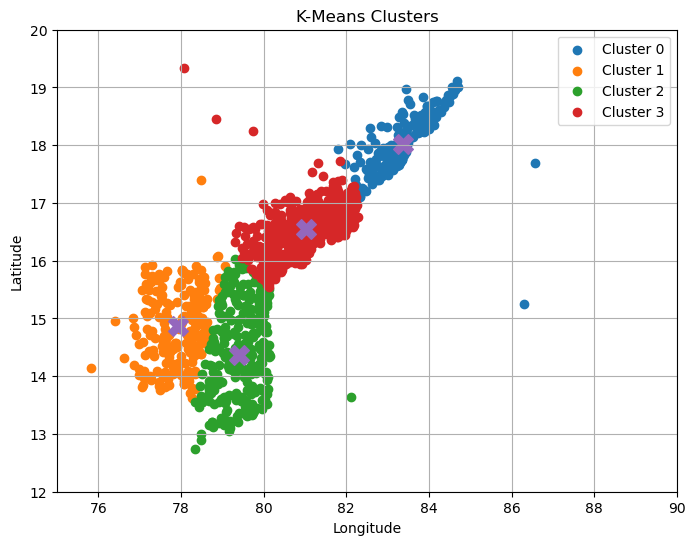

In [ ]:
#VISUALIZE CLUSTERS
plt.figure(figsize=(8,6))

for i in range(k):
    cluster_points = X[labels == i]
    plt.scatter(cluster_points[:,0], cluster_points[:,1], label=f"Cluster {i}")

# plot centroids
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200)

plt.title(f"K-Means Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(75, 90)
plt.ylim(12, 20)
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Testing predictions
def predict(X_test, centroids):
    labels = []

    for point in X_test:
        distances = []

        for centroid in centroids:
            dist = np.sqrt((point[0] - centroid[0])**2 +
                           (point[1] - centroid[1])**2)
            distances.append(dist)

        cluster = np.argmin(distances)
        labels.append(cluster)

    return np.array(labels)

# Example test data
test_data = np.array([
    [80.5, 16.7],
    [78.2, 14.9],
    [83.1, 17.5]
])

test_labels = predict(test_data, centroids)

# Print predictions
print("\nTest Data Predictions:")
for i, point in enumerate(test_data):
    print(f"Point {point} → Cluster {test_labels[i]}")


Test Data Predictions:
Point [80.5 16.7] → Cluster 3
Point [78.2 14.9] → Cluster 1
Point [83.1 17.5] → Cluster 0
